In [1]:
import os
import logging
import shutil
from pathlib import Path
import geopandas as gpd
import pandas as pd
from shapely.geometry import MultiPolygon
from dotenv import load_dotenv
import geopandas as gpd
from shapely.geometry import box
import logging
from func_file_io import load_data
from func_data_preprocessing import extract_s1cd_filename_part, calculate_area_in_km2_s1cd
from concurrent.futures import ProcessPoolExecutor
import xarray as xr
from func_s1cd_preprocessing import (
    drop_unnecessary_vars,
    rename_variables,
    merge_shapefiles,
    process_and_filter_usda_polygons,
    extract_polygons_from_mask,
    apply_tcc_mask,
    load_and_preprocess_dataset,
    extract_year_from_s1cd_filename,
    calculate_and_filter_area
)
import seaborn as sns
import geopandas as gpd
from shapely.geometry import box, shape
import rasterio.features
import numpy as np
import os
import logging
import xarray as xr
import rioxarray
import pandas as pd
from tqdm import tqdm
from func_file_io import load_data
from affine import Affine
from pyproj import Transformer
from func_data_preprocessing import extract_s1cd_filename_part, calculate_area_in_km2_s1cd

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.patches as mpatches
from matplotlib import ticker
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.patches as mpatches
from matplotlib import ticker

from matplotlib.lines import Line2D

# Fix Bug TCC

In [ ]:
def _validate_directory(directory_path, dir_name):
    """Check if a directory exists, create it if not, and log the status."""
    dir_path = Path(directory_path)
    
    if not dir_path.exists():
        dir_path.mkdir(parents=True, exist_ok=True)
        logging.info(f"{dir_name} directory was missing. Created at {dir_path}")
    else:
        logging.info(f"{dir_name} is valid at {dir_path}")


In [ ]:
env_path = '/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/environment/.env'

load_dotenv(dotenv_path=env_path)

region = os.getenv('REGION')
region_id = str(region).zfill(2)
# Set target CRS (Coordinate Reference System)
target_crs = os.getenv('TARGET_CRS')
equi7_crs = os.getenv('EQUI7_NA_EPSG')

    # Set directory paths from environment variables
input_dir = os.getenv('SENTINEL1_TILES_DIR')
ids_filtered = os.path.join(os.getenv('RESULTS_DIR'), os.getenv('IDS_FILTERED_FILE').format(region_id=region_id))
s1_tiles_boundary_path =  os.path.join(os.getenv('RESULTS_DIR'), os.getenv('S1CD_TILES_BOUNDS_FILE').format(region_id=region_id))

intermediate_dir = os.getenv('INTERMEDIATE_FILES_DIR')
metadata_dir = os.getenv('METADATA_FILES_DIR')

    # Validate that the required directories exist
_validate_directory(input_dir, "Input directory")
_validate_directory(intermediate_dir, "Intermediate directory")
_validate_directory(metadata_dir, "Metadata directory")


In [ ]:
def apply_tcc_mask(dataset, tcc_raster_path):
    """
    Applies a Tree Canopy Cover (TCC) mask to the dataset based on the TCC raster file.

    The function subsets the TCC raster based on the dataset's spatial extent, interpolates 
    the TCC data to match the dataset's grid, and applies a mask to retain only the areas 
    where the TCC value exceeds a specified threshold.

    Parameters:
    - dataset (xarray.DataArray): The input dataset to be masked.
    - tcc_raster_path (str): Path to the TCC 2017 raster file.

    Returns:
    - xarray.DataArray: The masked dataset where TCC values are above the threshold.
      Returns `None` if an error occurs at any step.
    """
    threshold = 0.3
    # Step 1: Load the TCC raster data from the provided file path
    logging.info("Loading TCC raster data from: %s", tcc_raster_path)
    
    try:
        tcc_data = rioxarray.open_rasterio(tcc_raster_path)
    except Exception as e:
        logging.error("Failed to open TCC raster: %s", e)
        return None

      # CRS of both datasets
    ds_crs = dataset.rio.crs
    tcc_crs = tcc_data.rio.crs

    if ds_crs is None or tcc_crs is None:
        logging.error("Missing CRS information in dataset or TCC raster.")
        return None

    # Extract bounds from dataset
    dataset_lon_min = float(dataset['x'].min())
    dataset_lon_max = float(dataset['x'].max())
    dataset_lat_min = float(dataset['y'].min())
    dataset_lat_max = float(dataset['y'].max())

    logging.info("Dataset bounds (original CRS %s): x=[%f,%f], y=[%f,%f]",
                 ds_crs, dataset_lon_min, dataset_lon_max,
                 dataset_lat_min, dataset_lat_max)

    # Transform bounds into TCC CRS
    transformer = Transformer.from_crs(ds_crs, tcc_crs, always_xy=True)

    x_min_tcc, y_min_tcc = transformer.transform(dataset_lon_min, dataset_lat_min)
    x_max_tcc, y_max_tcc = transformer.transform(dataset_lon_max, dataset_lat_max)
    x_min_tcc2, y_max_tcc2 = transformer.transform(dataset_lon_min, dataset_lat_max)
    x_max_tcc2, y_min_tcc2 = transformer.transform(dataset_lon_max, dataset_lat_min)

    # Get overall bounding box (since reprojection can flip axes)
    x_min = min(x_min_tcc, x_min_tcc2, x_max_tcc, x_max_tcc2)
    x_max = max(x_min_tcc, x_min_tcc2, x_max_tcc, x_max_tcc2)
    y_min = min(y_min_tcc, y_min_tcc2, y_max_tcc, y_max_tcc2)
    y_max = max(y_min_tcc, y_min_tcc2, y_max_tcc, y_max_tcc2)

    logging.info("Transformed bounds in TCC CRS (%s): x=[%f,%f], y=[%f,%f]",
                 tcc_crs, x_min, x_max, y_min, y_max)

     # Subset TCC raster in its CRS
    try:
        tcc_subset = tcc_data.sel(
            x=slice(x_min, x_max),
            y=slice(y_max, y_min)  # note reversed y order
        )
    except Exception as e:
        logging.error("Failed to subset TCC raster: %s", e)
        return None

    if tcc_subset.rio.bounds() is None or tcc_subset.size == 0:
        logging.error("TCC subset is empty after reprojection.")
        return None

    # Reproject TCC subset to dataset CRS & grid
    try:
        tcc_reproj = tcc_subset.rio.reproject_match(dataset)
    except Exception as e:
        logging.error("Failed to reproject TCC subset to dataset grid: %s", e)
        return None

    # Apply mask
    mask = tcc_reproj.squeeze() > threshold
    masked = dataset.where(mask)

    return masked, tcc_reproj

    # # Step 2: Extract the spatial bounds of the dataset (longitude and latitude ranges)
    # dataset_lon_min, dataset_lon_max = dataset['x'].min(), dataset['x'].max()
    # dataset_lat_min, dataset_lat_max = dataset['y'].min(), dataset['y'].max()

    # logging.info("Dataset spatial bounds - Longitude: [%f, %f], Latitude: [%f, %f]",
    #             dataset_lon_min, dataset_lon_max, dataset_lat_min, dataset_lat_max)

    # # Step 3: Subset the TCC raster to the region of interest (dataset spatial bounds)
    # logging.info("Extracting TCC data subset within dataset bounds...")
    # tcc_subset = tcc_data.sel(x=slice(dataset_lon_min, dataset_lon_max),
    #                           y=slice(dataset_lat_max, dataset_lat_min))

    # # Step 4: Check if the subset is valid, return None if empty
    # if tcc_subset.isnull().all():
    #     logging.error("TCC data subset is empty for the given bounds.")
    #     return None

    # # Step 5: Interpolate the TCC data to match the dataset's grid (coordinate system)
    # logging.info("Interpolating TCC data to match dataset grid...")
    # try:
    #     interpolated_tcc = tcc_subset.interp(x=dataset.coords['x'], y=dataset.coords['y'], method='nearest')
    # except Exception as e:
    #     logging.error("Interpolation failed: %s", e)
    #     return None

    # # Step 6: Apply the TCC mask to the dataset
    # # Only retain values where the TCC is above the specified threshold (0.3 in this case)
    # logging.info("Masking dataset based on TCC values...")
    # threshold = 0.3
    # masked_dataset = dataset.where(interpolated_tcc > threshold, 0).fillna(0)

    # # Step 7: Return the masked dataset
    # logging.info("Masking complete. Returning masked dataset.")
    
    # return masked_dataset


In [ ]:
def extract_polygons_from_mask(filename, masked_data_array):
    """
    Extracts polygons from a masked data array, storing them in a GeoDataFrame 
    with metadata (year and tile) parsed from the filename.

    Parameters:
    - filename (str): The filename containing year and tile information.
    - masked_data_array (xarray.DataArray): The masked data array with 'x' and 'y' coordinates 
      and a 'layer' attribute representing the mask layer.

    Returns:
    - GeoDataFrame: A GeoDataFrame containing extracted polygons with year and tile metadata.
    """
    
    # Step 1: Parse the year and tile name from the filename
    year = int(filename.split('_year_')[-1].split('_')[0])
    tile_name = filename[13:23]  # Extract tile name based on the assumed naming convention
    
    # Step 2: Initialize an empty GeoDataFrame to store the polygons
    results_gdf = gpd.GeoDataFrame(columns=['geometry', 'S1_YEAR', 'S1_TILE'], crs="EPSG:4326")
    
    # Step 3: Extract the bounding box coordinates (min and max) from the masked data array
    min_x, max_x = masked_data_array['x'].min().item(), masked_data_array['x'].max().item()
    min_y, max_y = masked_data_array['y'].min().item(), masked_data_array['y'].max().item()
    
    # Step 4: Create a GeoDataFrame to represent the bounding box of the data array
    bounds_gdf = gpd.GeoDataFrame(geometry=[box(min_x, min_y, max_x, max_y)], crs="EPSG:4326")
    
    # Step 5: Drop the 'band' dimension only if it exists
    if "band" in masked_data_array.dims:
        cropped_mask = masked_data_array.squeeze("band")
    else:
        cropped_mask = masked_data_array

    
    # Step 6: Define the affine transformation to map array indices to geospatial coordinates
    transform = (
        Affine.translation(cropped_mask.x[0], cropped_mask.y[0]) * 
        Affine.scale(cropped_mask.x[1] - cropped_mask.x[0], cropped_mask.y[1] - cropped_mask.y[0])
    )
    
    # Step 7: Create a binary mask where values greater than zero are set to 1 (True)
    binary_mask = (cropped_mask['layer'] > 0).astype(np.uint8)
    
    # Step 8: Extract polygon shapes from the binary mask, using the affine transformation
    extracted_shapes = list(rasterio.features.shapes(binary_mask.values, transform=transform))
    
    # Step 9: Filter and keep only the polygons with a value of 1 (representing valid mask regions)
    polygons = [shape(geom) for geom, value in extracted_shapes if value == 1]
    
    # Step 10: Create a GeoDataFrame from the list of extracted polygons
    polygons_gdf = gpd.GeoDataFrame(geometry=polygons, crs=cropped_mask.spatial_ref)
    
    # Step 11: Add metadata columns (year and tile) to the GeoDataFrame
    polygons_gdf['S1_YEAR'] = year
    polygons_gdf['S1_TILE'] = tile_name
    
    # Step 12: Append the new polygons to the results GeoDataFrame
    results_gdf = pd.concat([results_gdf, polygons_gdf], ignore_index=True)
    
    # Return the final GeoDataFrame containing all extracted polygons with metadata
    return results_gdf

In [ ]:
# Step 1: Extract year from the Sentinel-1 Cloud Data filename
input_file = '/net/projects/forexd/WP1/Data/S1_TILES_R8/s1_change_detection_northamerica/EQUI7_NA020M_E084N027T3_rqatrend_VH_A_thresh_3.0_year_2016_cluster_compressed.nc'
s1_year = extract_year_from_s1cd_filename(input_file)
filename = os.path.basename(input_file)
print(f"Processing file: {input_file} for year {s1_year}")

# Step 2: Load and preprocess the input raster dataset
print(f"Loading and preprocessing dataset from {input_file}...")
dataset = load_and_preprocess_dataset(input_file)

# Step 3: Apply Tree Canopy Cover (TCC) mask if path is provided
crs = os.getenv('TCC_CRS')
crs_number = crs.split(":")[-1] if crs else None
tcc_path = os.path.join(os.getenv('TCC_DIR'),
                        os.getenv('TCC_NORMALIZED_RASTER_TEMPLATE').format(region_id=region_id,
                                                                                crs=crs_number,
                                                                                tcc_year=(s1_year-1)))
if tcc_path:
    logging.info(f"Applying TCC mask from {tcc_path}...")
    dataset_masked = apply_tcc_mask(dataset, tcc_path)

# # Step 4: Extract polygons from the masked dataset
# logging.info("Extracting polygons from the masked dataset...")
# dataset = extract_polygons_from_mask(filename, dataset)
dataset_masked

In [ ]:
dataset.layer.plot()

In [ ]:
dataset_masked.layer.plot()

In [ ]:
dataset_extracted = extract_polygons_from_mask(filename, dataset_masked)
dataset_extracted

In [ ]:
dataset_extracted.plot()

In [ ]:
from func_helper import parse_custom_colors
load_dotenv(dotenv_path=env_path)

# Load environment variables and validate
region = os.getenv('REGION')
if not region:
    raise ValueError("The 'REGION' environment variable is not set.")
region_id = str(region).zfill(2)
# Set target CRS (Coordinate Reference System)
target_crs = os.getenv('TARGET_CRS')

custom_colors_json = os.getenv('COLORS')
custom_colors = parse_custom_colors(custom_colors_json)


# Define file paths for shapefiles and output locations
usa_filepath = os.path.join(os.getenv('REGION_SHAPE_DIR'), os.getenv('REGION_SHAPE_FILE'))
ids_path = os.path.join(os.getenv('RESULTS_DIR'), os.getenv('IDS_FILTERED_FILE').format(region_id=region_id))
crs = os.getenv('TCC_CRS')
tcc_year = 2015
crs_number = crs.split(":")[-1] if crs else None
tcc_downsampled = os.path.join(os.getenv('TCC_DIR'), 
                                    os.getenv('TCC_NORMALIZED_RASTER_TEMPLATE').format(region_id=region_id,
                                                                                    crs=crs_number,
                                                                                    tcc_year=2017))
s1_tiles_boundary_path =  os.path.join(os.getenv('RESULTS_DIR'), os.getenv('S1CD_TILES_BOUNDS_FILE').format(region_id=region_id))


In [ ]:
input_tiff = os.path.join(os.getenv('TCC_DIR'), os.getenv('TCC_NORMALIZED_RASTER_TEMPLATE').format(region_id=region_id, tcc_year=tcc_year, crs=crs_number))
region_shape_path = os.path.join(os.getenv('REGION_SHAPE_DIR'), os.getenv('REGION_SHAPE_FILE'))
region = os.getenv('REGION')
region_id = str(region).zfill(2)
temp_netcdf = os.path.join(os.getenv('TCC_DIR'), os.getenv('TCC_DOWNSAMPLED_TEMP_RASTER_TEMPLATE').format(region_id=region_id, tcc_year=tcc_year, crs=crs_number))
final_netcdf = os.path.join(os.getenv('TCC_DIR'), os.getenv('TCC_DOWNSAMPLED_RASTER_TEMPLATE').format(region_id=region_id, tcc_year=tcc_year, crs=crs_number))
from func_helper import load_and_extract_region

In [ ]:
# Load raster
forest_cover = rioxarray.open_rasterio(input_tiff, masked=True).squeeze()
# Ensure CRS
forest_cover = forest_cover.rio.write_crs("EPSG:4326")
forest_cover

In [ ]:
target_crs='EPSG:4326'

# Load the shapefile data from the specified path
usa_shape = gpd.read_file(region_shape_path)
    
# Filter for the specified region using the region_id
region = usa_shape[usa_shape['REGION'] == region_id]

# Explode geometries to ensure each part of multi-part geometries is separate,
# then select only the largest part (first in the sequence)
region_conus = region.explode(index_parts=False).iloc[0:1]

# Reproject the region to the target CRS
region_conus = region_conus.to_crs(target_crs)
region_conus

In [ ]:
# Load region geometry
region_geometry = load_and_extract_region(region_shape_path, region_id).union_all()
region_geometry

In [ ]:
downsample_factor = 100
forest_cover = forest_cover.coarsen(x=downsample_factor, y=downsample_factor, boundary='trim').mean()
forest_cover  

In [ ]:
print(forest_cover)

In [ ]:
region_gdf = gpd.read_file(region_shape_path)
region = region_gdf[region_gdf['REGION'] == region_id]
region.crs
print(region_geometry.bounds)


In [ ]:
tcc.rio.write_crs("EPSG:27705", inplace=True)


In [ ]:
import geopandas as gpd
import rioxarray
import xarray as xr


forest_cover.to_netcdf(temp_netcdf)

# Optional weiterverarbeiten
processed_data = xr.open_dataset(temp_netcdf).rename({'__xarray_dataarray_variable__': 'tcc'})
if 'spatial_ref' in processed_data:
    processed_data = processed_data.drop_vars('spatial_ref')


# Alle Werte >= 1 zu NaN machen
processed_data['tcc'] = processed_data['tcc'].where(processed_data['tcc'] < 1, np.nan)

# Speichern
processed_data.to_netcdf(final_netcdf, mode='w')

print(f"Successfully saved the final NetCDF file to {final_netcdf}")


In [ ]:
import geopandas as gpd
import rioxarray
import matplotlib.pyplot as plt

# 1️⃣ GeoDataFrame laden
region_gdf = gpd.read_file(region_shape_path)

# 2️⃣ Nur die gewünschte Region auswählen
region = region_gdf[region_gdf['REGION'] == region_id]  # <-- Das ist jetzt ein GeoDataFrame

# 3️⃣ NetCDF laden
ds = xr.open_dataset(final_netcdf)
tcc = ds['tcc']

# 4️⃣ CRS für das Raster setzen, falls nötig
tcc = tcc.rio.write_crs("EPSG:4326")

# 5️⃣ CRS der Region anpassen
region_proj = region.to_crs(tcc.rio.crs)

# 6️⃣ Alle Polygone zu einem zusammenführen
region_geometry = region_proj.unary_union

tcc.rio.write_crs("EPSG:27705", inplace=True)

region_proj = region.to_crs("EPSG:27705")
region_geometry = region_proj.unary_union

# 7️⃣ Clip
cropped_tcc = tcc.rio.clip([region_geometry], "EPSG:27705", drop=True, from_disk=True)


# 8️⃣ Plotten
plt.figure(figsize=(12, 8))
cropped_tcc.plot(cmap='Greens')
plt.title("Cropped Forest Cover")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [ ]:
# # Load region geometry
# region_geometry = load_and_extract_region(region_shape_path, region_id).union_all()
# #region_gdf = region_gdf.to_crs(forest_cover.rio.crs)  # Ensure same CRS

# # Load and ensure CRS of forest cover map
# #forest_cover = rioxarray.open_rasterio(input_tiff, masked=True).squeeze()
# region_geometry = region_geometry.to_crs(forest_cover.rio.crs)

# #forest_cover = forest_cover.rio.write_crs("EPSG:4326")

# # Downsample the raster data
# downsample_factor = 100
# forest_cover = forest_cover.coarsen(x=downsample_factor, y=downsample_factor, boundary='trim').mean()

# Crop to region
cropped_forest_cover = forest_cover.rio.clip([region_geometry], forest_cover.rio.crs, drop=True, from_disk=True)
cropped_forest_cover.to_netcdf(temp_netcdf)

# Load and process the cropped NetCDF file
processed_data = xr.open_dataset(temp_netcdf).rename({'__xarray_dataarray_variable__': 'tcc'})
processed_data = processed_data.drop_vars('spatial_ref')

# Save the final NetCDF file
processed_data.to_netcdf(final_netcdf, mode='w')

print(f"Successfully saved the final NetCDF file to {final_netcdf}")
    


# Fix Plotting Bug

In [2]:
from func_plots import plot_study_area, plot_radar_reduction_potential, plot_d_area_ch_area_centroid_disturbances, plot_disturbance_signal_duration, plot_signal_counts_by_diff_year_combined, plot_percentages_histograms
from func_helper import parse_custom_colors, format_label, calculate_area_in_km2, calculate_minimum_outerline_area, add_signal_duration_column, remove_drought, closest_s1_year, merge_geometries_and_keep_columns
from func_file_io import load_data
from func_preprocessing import calculate_size_shift_difference
from func_tcc_application import create_downsampled_tcc_map
import os
import logging
from pathlib import Path
from dotenv import load_dotenv
import concurrent.futures
import xarray as xr
import pandas as pd
import geopandas as gpd
import numpy as np
import rasterio
from affine import Affine
from shapely.geometry import box, shape

env_path = '/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/environment/.env'
load_dotenv(dotenv_path=env_path)

# Load environment variables and validate
region = os.getenv('REGION')
if not region:
    raise ValueError("The 'REGION' environment variable is not set.")
region_id = str(region).zfill(2)
# Set target CRS (Coordinate Reference System)
target_crs = os.getenv('TARGET_CRS')
custom_colors_json = os.getenv('COLORS')
custom_colors = parse_custom_colors(custom_colors_json)


        # Define file paths for shapefiles and output locations
usa_filepath = os.path.join(os.getenv('REGION_SHAPE_DIR'), os.getenv('REGION_SHAPE_FILE'))
ids_path = os.path.join(os.getenv('RESULTS_DIR'), os.getenv('IDS_FILTERED_FILE_ESPG_4326').format(region_id=region_id))
crs = os.getenv('TCC_CRS')
crs_number = crs.split(":")[-1] if crs else None
buffer = 500
ids_gdf = load_data(ids_path)
# Get figure file paths from environment variables with dynamic buffer and region ID replacement
figure_radar_reduction_potential_path = os.path.join(os.getenv('FIGURES_DIR'), os.getenv('FIGURE_RADAR_REDUCTION').format(buffer=buffer))
figure_year_lag_path = os.path.join(os.getenv('FIGURES_DIR'), os.getenv('FIGURE_YEAR_LAG').format(buffer=buffer))
figure_size_position_change_path =  os.path.join(os.getenv('FIGURES_DIR'), os.getenv('FIGURE_SIZE_CHANGE').format(buffer=buffer))
figure_overlap_percentage_path =  os.path.join(os.getenv('FIGURES_DIR'), os.getenv('FIGURE_OVERLAP').format(buffer=buffer))

s1dm_path = os.path.join(os.getenv('RESULTS_DIR'), os.getenv('S1DM_SHAPE_FILE').format(region_id=region_id, buffer=buffer))

ids_gdf = load_data(ids_path)
s1dm_gdf = load_data(s1dm_path)

refdm_gdf_yearly_aggregated = merge_geometries_and_keep_columns(s1dm_gdf)
s1dm_frequency = add_signal_duration_column(refdm_gdf_yearly_aggregated, target_crs)
s1dm_cleaned = remove_drought(s1dm_frequency)
logging.info('Claculate size shift difference')
gdf = calculate_size_shift_difference(ids_gdf, s1dm_cleaned)
# Minimum outerline areas
s1dm_convex = calculate_minimum_outerline_area(s1dm_cleaned)[['geometry', 'area_km2', 'DCA_ID']]
ids_convex = calculate_minimum_outerline_area(ids_gdf)[['geometry', 'area_km2', 'DCA_ID']]

# Remove drought disturbances
s1dm_no_drought = remove_drought(s1dm_cleaned)
s1dm_no_drought_gdf = remove_drought(s1dm_gdf)

Loading shapefile from: /net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1//results/region_08_dca_filtered_ids_usda_polygons.shp
Loading shapefile from: /net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1//results/region_08_dca_filtered_ids_usda_polygons.shp
Loading shapefile from: /net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1//results/radar_enhanced_forest_disturbance_mapping_region_08_buffer_500_s1dm.shp


/net/home/fmueller/.conda/envs/emp/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/net/home/fmueller/.conda/envs/emp/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/net/home/fmueller/.conda/envs/emp/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a 

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import logging

def format_ticks(x, pos):
    """Format the ticks to always have one decimal place."""
    return f'{x:.1f}'

def plot_d_area_ch_area_centroid_disturbances_test(
        gdf, ids, s1dm_convex, ids_convex, custom_colors, save_path
    ):
    """
    Plot comparison between IDS and REFDM disturbance areas and centroid shifts,
    with legend inside the centroid shift plot. Includes safety checks and 
    recalculation of centroids to avoid NaNs.
    """

    # Determine the unique DCA_ID values from the filtered dataframe
    unique_dca_ids = gdf['DCA_ID'].unique()

    # Sort the categories based on the custom order
    category_order = sorted(unique_dca_ids, key=lambda x: custom_colors.get(x, x))  
    default_palette = sns.color_palette('tab10', n_colors=10)
    default_colors = [color for color in default_palette if color not in custom_colors.values()]

    # Combine the custom colors with the default colors
    custom_palette = {label: custom_colors.get(label, default_colors.pop(0)) for label in category_order}

    sns.set(style="whitegrid")

    n_categories = len(category_order)
    n_cols = 3  # Fixed number of columns
    fig, axs = plt.subplots(
        n_categories, 
        n_cols, 
        figsize=(40, 8 * n_categories), 
        gridspec_kw={'width_ratios': [3, 3, 2], 'wspace': 0.3} # Reduce the width ratios for empty columns
    )

    
    fontsize_supertitle = 44
    fontsize_legend = 40
    fontsize_title = 46
    fontsize_label = 50
    fontsize_tick = 35
    padding_label = 25
    padding_title = 25

    for i, category in enumerate(category_order):
        # Create combined data for violin plots using .loc[] to avoid SettingWithCopyWarning
        combined_data = pd.concat([
            #ids.loc[ids['DCA_ID'] == category, ['DCA_ID', 'area_km2']].assign(Source='IDS'),
            ids.loc[ids['DCA_ID'] == category, ['DCA_ID', 'area_km2']].copy().assign(Source='IDS'),
            #gdf.loc[gdf['DCA_ID'] == category, ['DCA_ID', 'area_km2']].assign(Source='REFDM')
            gdf.loc[gdf['DCA_ID'] == category, ['DCA_ID', 'area_km2']].assign(Source='REFDM')
        ])

        combined_convex = pd.concat([
            ids_convex.loc[ids_convex['DCA_ID'] == category, ['DCA_ID', 'area_km2']].assign(Source='IDS'),
            s1dm_convex.loc[s1dm_convex['DCA_ID'] == category, ['DCA_ID', 'area_km2']].assign(Source='REFDM')
        ])

        ax = axs[i, 0]
        data_refdm = combined_data.loc[(combined_data['Source'] == 'REFDM') & (combined_data['DCA_ID'] == category)]
        data_ids = combined_data.loc[(combined_data['Source'] == 'IDS') & (combined_data['DCA_ID'] == category)]

        median_refdm = np.median(data_refdm['area_km2'])
        median_ids = np.median(data_ids['area_km2'])

        if np.isnan(median_ids) or np.isnan(median_refdm):
            logging.warning(f"No valid data for category {category}, skipping KDE.")
            continue  # Skip this category completely

        ax.axvline(x=0, color='black', linestyle='-', linewidth=2)
        
        # Plot KDE for IDS
        sns.kdeplot(
            data=data_ids['area_km2'],
            color='black',
            ax=ax,
            common_norm=True,
            linewidth=4,
            label='IDS',
            alpha=0.8,
            linestyle='-'
        )

        # Plot KDE for REFDM
        sns.kdeplot(
            data=data_refdm['area_km2'],
            color=custom_palette[category],
            ax=ax,
            common_norm=True,
            linewidth=4,
            label='S1DM',
            alpha=1,
            linestyle='-'
        )

        # Calculate the 90th percentile for disturbance area
        percentile_90_refdm = np.percentile(data_refdm['area_km2'], 90)
        percentile_90_ids = np.percentile(data_ids['area_km2'], 90)


        print(f"Median IDS for category {category}: {median_ids} km²")
        print(f"Median S1DM for category {category}: {median_refdm} km²")
        print(f"90th Percentile IDS for category {category}: {percentile_90_ids} km²")
        print(f"90th Percentile S1DM for category {category}: {percentile_90_refdm} km²")

        # # Add vertical lines at the 90th percentile
        # ax.axvline(x=percentile_90_ids, color='black', linestyle=':', linewidth=3, alpha=0.8, label=f'IDS 90th: {percentile_90_ids:.2f}', marker='o', markersize=16)
        # ax.axvline(x=percentile_90_refdm, color=custom_palette[category], linestyle=':', linewidth=3, alpha=1, label=f'S1DM 90th: {percentile_90_refdm:.2f}', marker='s', markersize=16)

        # Adjust median formatting for Bark Beetle DCA_ID
        if category == 'bark_beetle':
            median_refdm_label = f'S1DM Median: {median_refdm:.4f}' if median_refdm > 0 else 'S1DM Median: 0.0'
            median_ids_label = f'IDS Median: {median_ids:.4f}' if median_ids > 0 else 'IDS Median: 0.0'
        else:
            median_refdm_label = f'S1DM Median: {median_refdm:.2f}'
            median_ids_label = f'IDS Median: {median_ids:.2f}'

        from scipy.stats import gaussian_kde

        # Calculate KDE for IDS
        kde_ids = gaussian_kde(data_ids['area_km2'])
        x_vals_ids = np.linspace(min(data_ids['area_km2']), max(data_ids['area_km2']), 1000)
        kde_vals_ids = kde_ids(x_vals_ids)
        kde_at_median_ids = kde_ids(median_ids)[0]  # KDE value at median

        # Draw the median line for IDS
        ax.plot([median_ids, median_ids], [0, kde_at_median_ids], color='black', linestyle='--', linewidth=3, alpha=0.8, label=median_ids_label)
        ax.plot(median_ids, kde_at_median_ids, 'o', color='black', markersize=10)  # Dot at the median peak

        # Calculate KDE for REFDM
        kde_refdm = gaussian_kde(data_refdm['area_km2'])
        x_vals_refdm = np.linspace(min(data_refdm['area_km2']), max(data_refdm['area_km2']), 1000)
        kde_vals_refdm = kde_refdm(x_vals_refdm)
        kde_at_median_refdm = kde_refdm(median_refdm)[0]  # KDE value at median

        # Draw the median line for REFDM
        ax.plot([median_refdm, median_refdm], [0, kde_at_median_refdm], color=custom_palette[category], linestyle='--', linewidth=3, alpha=1, label=median_refdm_label)
        ax.plot(median_refdm, kde_at_median_refdm, 'o', color=custom_palette[category], markersize=10)  # Dot at the median peak

        ax.tick_params(axis='y', labelsize=fontsize_tick)
        ax.tick_params(axis='x', labelsize=fontsize_tick)

        if i == len(category_order) - 1:  # Only set x-label for the bottom row
            ax.set_xlabel(r"${A_{\text{D}}\text{ (km²)} }$", fontsize=fontsize_label, labelpad=padding_label)
        else:
            ax.set_xlabel('', labelpad=padding_label)

        ax.set_ylabel(' ', fontsize=fontsize_label, labelpad=padding_label)

        # Set the x-ticks and limit to 4 while ensuring not to include 0
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, integer=True, prune=None))  # Prune limits for edge ticks
        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=3, prune='lower'))
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_ticks))

        ax.set_xlim(-0.01, 10)
        ax.set_ylim(0)
        ax.legend(fontsize=fontsize_tick)

        ax = axs[i, 1]
        data_refdm = combined_convex.loc[(combined_convex['Source'] == 'REFDM') & (combined_convex['DCA_ID'] == category)]
        data_ids = combined_convex.loc[(combined_convex['Source'] == 'IDS') & (combined_convex['DCA_ID'] == category)]

        median_refdm = np.median(data_refdm['area_km2'])
        median_ids = np.median(data_ids['area_km2'])
        

        ax.axvline(x=0, color='black', linestyle='-', linewidth=2)
        
        # Plot KDE for IDS
        sns.kdeplot(
            data=data_ids['area_km2'],
            color='black',
            ax=ax,
            common_norm=True,
            linewidth=4,
            label='IDS',
            alpha=0.8,
            linestyle='-'
        )

        # Plot KDE for REFDM
        sns.kdeplot(
            data=data_refdm['area_km2'],
            color=custom_palette[category],
            ax=ax,
            common_norm=True,
            linewidth=4,
            label='S1DM',
            alpha=1,
            linestyle='-'
        )

        #  # Calculate the 90th percentile for disturbance area
        percentile_90_refdm = np.percentile(data_refdm['area_km2'], 90)
        percentile_90_ids = np.percentile(data_ids['area_km2'], 90)


        print(f"Median IDS for category {category}: {median_ids} km²")
        print(f"Median S1DM for category {category}: {median_refdm} km²")
        print(f"90th Percentile IDS for category {category}: {percentile_90_ids} km²")
        print(f"90th Percentile S1DM for category {category}: {percentile_90_refdm} km²")

        # # Add vertical lines at the 90th percentile
        # ax.axvline(x=percentile_90_ids, color='black', linestyle=':', linewidth=3, alpha=0.8, label=f'IDS 90th: {percentile_90_ids:.2f}', marker='o', markersize=16)
        # ax.axvline(x=percentile_90_refdm, color=custom_palette[category], linestyle=':', linewidth=3, alpha=1, label=f'S1DM 90th: {percentile_90_refdm:.2f}', marker='s', markersize=16)

        # Adjust median formatting for Bark Beetle DCA_ID
        if category == 'bark_beetle':
            median_refdm_label = f'S1DM Median: {median_refdm:.4f}' if median_refdm > 0 else 'S1DM Median: 0.0'
            median_ids_label = f'IDS Median: {median_ids:.4f}' if median_ids > 0 else 'IDS Median: 0.0'
        else:
            median_refdm_label = f'S1DM Median: {median_refdm:.2f}'
            median_ids_label = f'IDS Median: {median_ids:.2f}'

        # ax.axvline(x=median_ids, color='black', linestyle='--', linewidth=3, alpha=0.8, label=median_ids_label, marker='o', markersize=16)
        # ax.axvline(x=median_refdm, color=custom_palette[category], linestyle='--', linewidth=3, alpha=1, label=median_refdm_label, marker='s', markersize=16)
        
        from scipy.stats import gaussian_kde

        # Calculate KDE for IDS
        kde_ids = gaussian_kde(data_ids['area_km2'])
        x_vals_ids = np.linspace(min(data_ids['area_km2']), max(data_ids['area_km2']), 1000)
        kde_vals_ids = kde_ids(x_vals_ids)
        kde_at_median_ids = kde_ids(median_ids)[0]  # KDE value at median

        # Draw the median line for IDS
        ax.plot([median_ids, median_ids], [0, kde_at_median_ids], color='black', linestyle='--', linewidth=3, alpha=0.8, label=median_ids_label)
        ax.plot(median_ids, kde_at_median_ids, 'o', color='black', markersize=10)  # Dot at the median peak

        # Calculate KDE for REFDM
        kde_refdm = gaussian_kde(data_refdm['area_km2'])
        x_vals_refdm = np.linspace(min(data_refdm['area_km2']), max(data_refdm['area_km2']), 1000)
        kde_vals_refdm = kde_refdm(x_vals_refdm)
        kde_at_median_refdm = kde_refdm(median_refdm)[0]  # KDE value at median

        # Draw the median line for REFDM
        ax.plot([median_refdm, median_refdm], [0, kde_at_median_refdm], color=custom_palette[category], linestyle='--', linewidth=3, alpha=1, label=median_refdm_label)
        ax.plot(median_refdm, kde_at_median_refdm, 'o', color=custom_palette[category], markersize=10)  # Dot at the median peak


        ax.tick_params(axis='y', labelsize=fontsize_tick)
        ax.tick_params(axis='x', labelsize=fontsize_tick)

        if i == len(category_order) - 1:  # Only set x-label for the bottom row
            ax.set_xlabel(r"${A_{\text{CH}}\text{ (km²)} }$", fontsize=fontsize_label, labelpad=padding_label)
        else:
            ax.set_xlabel('', labelpad=padding_label)

        ax.set_ylabel(' ', fontsize=fontsize_label, labelpad=padding_label)

        # Set the x-ticks and limit to 4 while ensuring not to include 0
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, integer=True, prune=None))  # Prune limits for edge ticks
        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=3, prune='lower'))
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_ticks))

        ax.set_xlim(-0.01, 15)
        ax.set_ylim(0)
        ax.legend(fontsize=fontsize_tick)


        # -----------------------------
        # Centroid shift histogram
        ax = axs[i, 2]
        sns.histplot(
            data=gdf.loc[gdf['DCA_ID'] == category],  # Use .loc[] to filter rows by DCA_ID
            x='centroid_shift_m',
            kde=True,
            line_kws={'linewidth': 4},
            color=custom_palette[category],
            ax=ax,
            stat='count'  # This ensures the histogram is using 'count' for the y-axis
        )

        # Calculate the median for the current category
        median_value = gdf.loc[gdf['DCA_ID'] == category, 'centroid_shift_m'].median()

        # Calculate the 90th percentile for the current category
        percentile_90_value = gdf.loc[gdf['DCA_ID'] == category, 'centroid_shift_m'].quantile(0.9)

        # Print the median and 90th percentile values
        print(f"Median for category {category}: {median_value} m")
        print(f"90th Percentile for category {category}: {percentile_90_value} m")
        # Format the median value (e.g., round to nearest integer)
        formatted_median = f"{int(round(median_value))}"  # Rounds to nearest integer, removes decimals

        # Get the histogram count and bin edges
        hist_data = ax.patches  # This gives us all the histogram bars
        bin_edges = [patch.get_x() for patch in hist_data] + [hist_data[-1].get_x() + hist_data[-1].get_width()]
        bin_width = bin_edges[1] - bin_edges[0]  # Assuming uniform bin widths

        # Calculate the KDE for the current category
        kde = gaussian_kde(gdf.loc[gdf['DCA_ID'] == category, 'centroid_shift_m'])
        kde_at_median = kde(median_value)[0]  # KDE value at median

        # Scale the KDE to the histogram's count scale
        n_total = len(gdf.loc[gdf['DCA_ID'] == category])  # Total number of data points
        hist_max = max([patch.get_height() for patch in hist_data])  # Maximum histogram height (count)

        # Adjust the KDE value based on histogram's maximum count and total data points
        scaled_kde = kde_at_median * n_total * bin_width

        # Plot the median line and adjust to the histogram's count scale
        ax.plot(
            [median_value, median_value], [0, scaled_kde],  # Extend only up to the scaled KDE value
            color=custom_palette[category],
            linestyle='--',
            linewidth=4,
            label=f"M: {formatted_median} m"
        )

        # Add a dot at the upper limit of the median line (on the scaled KDE curve)
        ax.plot(median_value, scaled_kde, 'o', color=custom_palette[category], markersize=20)


        if i == len(category_order) - 1:
            ax.set_xlabel(r"${\Delta_{\text{Centroid}} \text{ (m)} }$", fontsize=fontsize_label, labelpad=padding_label)
        else:
            ax.set_xlabel(' ', fontsize=fontsize_label, labelpad=padding_label)

        ax.tick_params(axis='x', labelsize=fontsize_tick)
        ax.tick_params(axis='y', labelsize=fontsize_tick)
        ax.set_xlim(-0.01, 2400)
        ax.set_ylabel(' ', fontsize=fontsize_label, labelpad=padding_label)

        # Set the x-ticks for centroid shifts
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4, prune=None))  # Prune limits for edge ticks
        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=3, prune='lower')) 

        # Add the custom legend
        ax.legend(handles=[
                        mpatches.Patch(color=custom_palette[category], label=format_label(category)),  # Main category label
                        Line2D([0], [0], color=custom_palette[category], linestyle='--', linewidth=2, label=f"M: {formatted_median} m")  # Median line legend
                    ],
                  loc='upper right', fontsize=fontsize_legend, frameon=True, fancybox=True, facecolor='white', edgecolor='black', 
                    handlelength=1,   
                    handleheight=0.5)

    # -----------------------------
    # Add common y-axis labels
    fig.text(0.07, 0.5, r"${PDF}$", va='center', rotation='vertical', fontsize=fontsize_label)
    fig.text(0.39, 0.5, r"${PDF}$", va='center', rotation='vertical', fontsize=fontsize_label)
    fig.text(0.69, 0.5, r"${N_{\text{Events}}}$", va='center', rotation='vertical', fontsize=fontsize_label)

    fig.tight_layout()
    plt.savefig(save_path, dpi=400, bbox_inches='tight')
    plt.show()


Median IDS for category wind: 0.4344739210369233 km²
Median S1DM for category wind: 0.375477739052864 km²
90th Percentile IDS for category wind: 5.060304647386616 km²
90th Percentile S1DM for category wind: 5.026341792585426 km²
Median IDS for category wind: 0.4344739210369233 km²
Median S1DM for category wind: 2.1475121867498936 km²
90th Percentile IDS for category wind: 5.060304647386616 km²
90th Percentile S1DM for category wind: 11.310552703801992 km²
Median for category wind: 329.57630556750104 m
90th Percentile for category wind: 755.7795490426672 m
Median IDS for category bark_beetle: 0.004617465344742082 km²
Median S1DM for category bark_beetle: 0.004348494737533 km²
90th Percentile IDS for category bark_beetle: 0.07564780592720964 km²
90th Percentile S1DM for category bark_beetle: 0.074021942885603 km²
Median IDS for category bark_beetle: 0.004617465344742082 km²
Median S1DM for category bark_beetle: 0.24744670669156427 km²
90th Percentile IDS for category bark_beetle: 0.07564

/tmp/ipykernel_4078031/4251079270.py:354: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


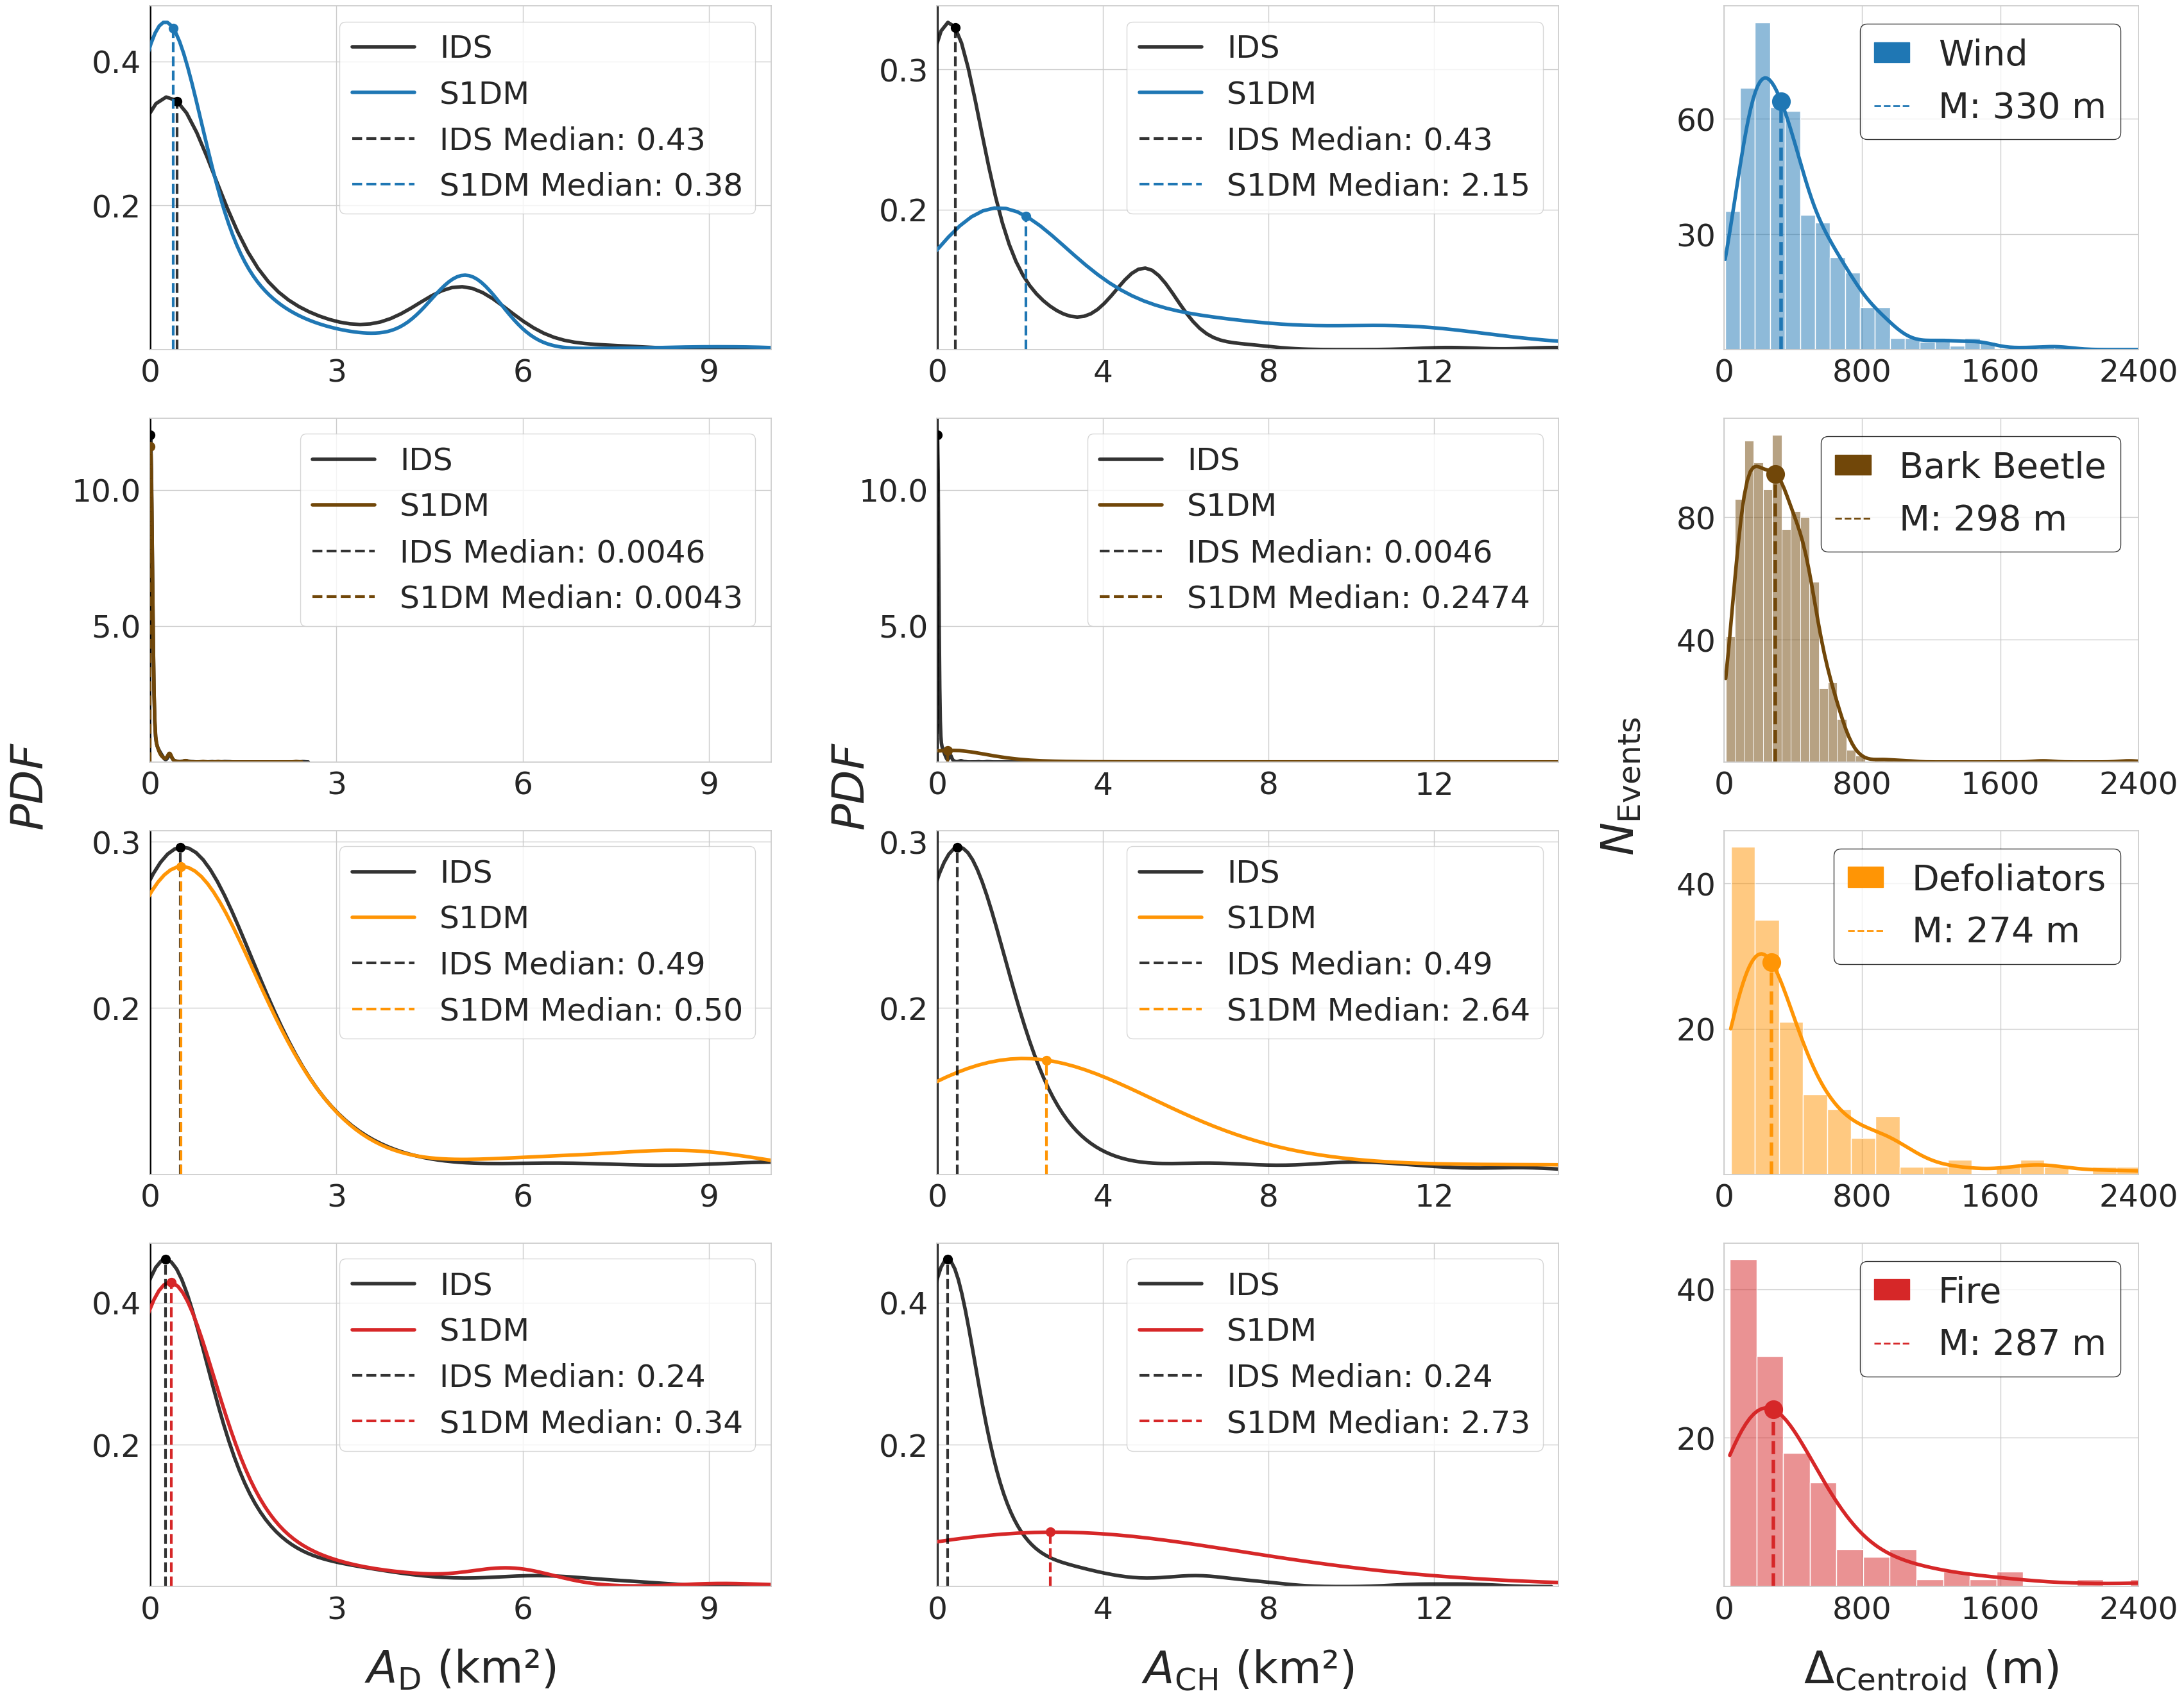

In [4]:
plot_d_area_ch_area_centroid_disturbances_test(
    gdf, 
    ids_gdf, 
    s1dm_convex, 
    ids_convex, 
    custom_colors, 
    save_path=figure_size_position_change_path
)

# Fix Bug Study Area Plotting

In [ ]:
import logging
import matplotlib.pyplot as plt
import pandas as pd  # Assuming you're using pandas for timestamps
import geopandas as gpd
from rasterio.plot import show
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable
from func_helper import format_label
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MaxNLocator, FuncFormatter
import numpy as np
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib import ticker
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import MaxNLocator, FuncFormatter
import matplotlib.ticker as ticker
from scipy.stats import gaussian_kde
from shapely.geometry import Polygon
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
from shapely import wkt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D
from pathlib import Path
import geopandas as gpd
from tqdm import tqdm 

from func_helper import parse_custom_colors, format_label, calculate_minimum_outerline_area, get_mainland, load_and_extract_region, calculate_overlap_percentages
from func_file_io import load_tcc_nc_dataset, load_data
from func_helper import parse_custom_colors
env_path = '/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/environment/.env'

load_dotenv(dotenv_path=env_path)

# Load environment variables and validate
region = os.getenv('REGION')
if not region:
    raise ValueError("The 'REGION' environment variable is not set.")
region_id = str(region).zfill(2)
# Set target CRS (Coordinate Reference System)
target_crs = os.getenv('TARGET_CRS')

custom_colors_json = os.getenv('COLORS')
custom_colors = parse_custom_colors(custom_colors_json)


# Define file paths for shapefiles and output locations
usa_filepath = os.path.join(os.getenv('REGION_SHAPE_DIR'), os.getenv('REGION_SHAPE_FILE'))
ids_path = os.path.join(os.getenv('RESULTS_DIR'), os.getenv('IDS_FILTERED_FILE').format(region_id=region_id))
crs = os.getenv('TCC_CRS')
crs_number = crs.split(":")[-1] if crs else None
tcc_downsampled = os.path.join(os.getenv('TCC_DIR'), 
                                    os.getenv('TCC_DOWNSAMPLED_RASTER_TEMPLATE').format(region_id=region_id,
                                                                                    crs=crs_number,
                                                                                    tcc_year=2017))
s1_tiles_boundary_path =  os.path.join(os.getenv('RESULTS_DIR'), os.getenv('S1CD_TILES_BOUNDS_FILE').format(region_id=region_id))

In [ ]:
def set_up_logging():
    """Set up logging to a file with timestamps for tracking the process."""
    logging.basicConfig(
        filename='log_plotter.log',
        level=logging.INFO, 
        format='%(asctime)s - %(message)s'
    )
set_up_logging()

In [ ]:
def plot_study_area(area_path, region_id, tcc_nc_path, s1_tiles_boundary_path, ids, custom_colors, save_path):
    logging.info("Load the USA Mainland and Region 8 Shape ...")
    mainland = get_mainland(area_path)
    region_8 = load_and_extract_region(area_path, region_id=region_id)

    logging.info("Load the TCC Region 8 Map ...")
    tcc_dataset = load_tcc_nc_dataset(tcc_nc_path)
    logging.info("Plot Study area figure ...")
    combine_study_area_plots(tcc_dataset, s1_tiles_boundary_path, mainland, region_8, ids, region_id, custom_colors, save_path, logging)

def combine_study_area_plots(cropped_forest, s1_tiles_boundary_path, usa_mainland, r8, gdf, region_id, custom_colors, save_path, logging):
    """
    Plot the TCC map with disturbance types and save the figure.
    """
    # Normalize the TCC values
    cropped_forest = normalize_tcc(cropped_forest)
    s1_tiles = load_data(s1_tiles_boundary_path)
    logging.info(f"s1_tiles contains {len(s1_tiles)} features")
    if s1_tiles.crs != cropped_forest.rio.crs:
        s1_tiles = s1_tiles.to_crs('EPSG:4326')

    # Set Seaborn style
    sns.set(style="whitegrid")
    
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))

    # Ensure s1_tiles, r8, and disturbances use the raster CRS
    target_crs = cropped_forest.rio.crs

    if s1_tiles.crs != target_crs:
        s1_tiles = s1_tiles.to_crs(target_crs)

    if r8.crs != target_crs:
        r8 = r8.to_crs(target_crs)

    if gdf.crs != target_crs:
        gdf = gdf.to_crs(target_crs)

    
    # Plot the entire USA in grey in the upper left corner
    #sub_ax = fig.add_axes([-0.05, 0.78, 0.25, 0.25])  # [left, bottom, width, height]
    sub_ax = fig.add_axes([0.02, 0.78, 0.20, 0.20])  
    plot_mainland_map(sub_ax, usa_mainland, region_id)
    
    # Create a custom colormap
    custom_cmap = create_custom_colormap()
    
    # Plot the TCC map within Region 8 boundaries
    plot_tcc_map(ax, cropped_forest, custom_cmap)
    
    # Plot the region outline
    r8.boundary.plot(ax=ax, linewidth=1, color='#000000')
    
     # Add a label in the center of Region 8
    ax.text(
        0.5, 0.92, "S1CD Tiles",  # Centered in x, slightly lower than before
        fontsize=16, fontweight='normal', color="black",  # Not bold
        ha='center', va='center',
        transform=ax.transAxes,  # Position relative to axis
        bbox=dict(facecolor='white', edgecolor='black')
    )

    # Plot disturbance types
    plot_disturbance_types(ax, gdf, custom_colors)
    
    # Customize the plot
    ax.axis('off')  # Remove axis and frame
    
    # Create legend for disturbance types
    legend_patches = [mpatches.Patch(color=color, label=format_label(disturbance)) for disturbance, color in custom_colors.items()]
    ax.legend(handles=legend_patches, fontsize=18, title="Disturbance Type", title_fontsize=20, loc='center left', facecolor='white', framealpha=1)
    
    s1_tiles.boundary.plot(ax=ax, edgecolor="black", linewidth=2)

    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

def normalize_tcc(cropped_forest):
    """
    Normalize the 'tcc' values in the cropped forest data to range between 0 and 100.
    """
    cropped_forest['tcc'] = (cropped_forest['tcc'] / cropped_forest['tcc'].max()) * 100
    cropped_forest['tcc'] = cropped_forest['tcc'].clip(min=0, max=100)
    return cropped_forest

def plot_mainland_map(ax, usa_mainland, region_id):
    """
    Plot the entire USA mainland with Region 8 highlighted.
    """
    usa_mainland[usa_mainland['REGION'] != region_id].plot(ax=ax, color='grey', edgecolor='grey')
    usa_mainland[usa_mainland['REGION'] == region_id].plot(ax=ax, color='black', edgecolor='black')
    ax.set_xlabel('Longitude', fontsize=18)
    ax.set_ylabel('Latitude', fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.grid(True)
    ax.axis('on')

def create_custom_colormap():
    """
    Create a custom colormap for the TCC plot.
    """
    cmap = plt.colormaps['Greens']
    new_colors = cmap(np.linspace(0, 1, 100))
    new_colors[0, :] = [1, 1, 1, 1]  # Set the first color (corresponding to 0) to white
    return LinearSegmentedColormap.from_list('CustomGreens', new_colors)

def plot_tcc_map(ax, cropped_forest, custom_cmap):
    """
    Plot the TCC map within Region 8 boundaries.
    """
    plot = cropped_forest['tcc'].plot(ax=ax, cmap=custom_cmap, add_colorbar=False, add_labels=False)
    cbar = plt.colorbar(plot, ax=ax, orientation='horizontal', pad=0.05, aspect=10, shrink=0.8)
    cbar.mappable.set_cmap(custom_cmap)
    #cbar.ax.set_position([0.15, 0.2, 0., 0.03])  # [left, bottom, width, height]
    cbar.ax.set_position([0.37, 0.35, 0.35, 0.03])  # [left, bottom, width, height]
    cbar.set_ticks([0, 25, 50, 75, 100])
    cbar.set_ticklabels(['0', '25', '50', '75', '100'])
    cbar.ax.tick_params(labelsize=16)
    cbar.set_label('Tree Canopy Cover (%)', fontsize=16, labelpad=6)
    cbar.ax.xaxis.set_label_position('top')
    cbar.ax.xaxis.label.set_size(16)
    cbar.ax.xaxis.labelpad = 10

def plot_disturbance_types(ax, refdm_dissolved, custom_colors):
    """
    Plot disturbance types within Region 8 with corresponding colors and white edges.
    """

    for disturbance, color in custom_colors.items():
        # Plot with white edge first
        refdm_dissolved[refdm_dissolved['DCA_ID'] == disturbance].plot(
            ax=ax, linewidth=3.5, color=color, edgecolor='white'
        )
        # Then plot with actual color and thinner edge
        refdm_dissolved[refdm_dissolved['DCA_ID'] == disturbance].plot(
            ax=ax, linewidth=2.5, color=color, edgecolor=color
        )


In [ ]:
figure_study_area_path = os.path.join(os.getenv('FIGURES_DIR'), os.getenv('FIGURE_STUDY_AREA').format(region_id=region_id))
ids_gdf = load_data(ids_path)
plot_study_area(
        usa_filepath, 
        region_id, 
        tcc_downsampled, 
        s1_tiles_boundary_path,
        ids_gdf, 
        custom_colors, 
        figure_study_area_path)